# Quantium Retail Analytics – Task 2

## Objective

The objective of this analysis is to evaluate the performance of trial stores (77, 86, 88) by comparing them with similar control stores. The goal is to determine whether the new store layout resulted in a measurable uplift in sales and customer behaviour.

We will follow a structured analytical approach involving:
- Control store selection
- Pre-trial comparison
- Trial impact assessment
- Statistical significance testing

## Load Required Libraries and Dataset

We begin by loading the dataset and preparing the required time-based variables.

In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('QVI_data.csv')

data['DATE'] = pd.to_datetime(data['DATE'])
data['YEARMONTH'] = data['DATE'].dt.year * 100 + data['DATE'].dt.month

data.head()

Saving QVI_data.csv to QVI_data.csv


,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,201810
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,201809
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,201903
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,201903
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,201811


The dataset has been successfully loaded and transformed. A new variable YEARMONTH has been created to enable monthly aggregation.

## Create Monthly Measures

We calculate key performance metrics for each store over time:
- Total sales
- Number of customers
- Transactions per customer

In [2]:
measureOverTime = data.groupby(['STORE_NBR','YEARMONTH']).agg({
    'TOT_SALES':'sum',
    'LYLTY_CARD_NBR':pd.Series.nunique,
    'TXN_ID':pd.Series.nunique
}).reset_index()

measureOverTime.rename(columns={
    'TOT_SALES':'totSales',
    'LYLTY_CARD_NBR':'nCustomers',
    'TXN_ID':'nTxn'
}, inplace=True)

measureOverTime['nTxnPerCust'] = measureOverTime['nTxn']/measureOverTime['nCustomers']

These measures allow us to evaluate store performance across multiple dimensions including sales and customer activity.

## Pre-Trial Filtering

We restrict the dataset to the pre-trial period (before Feb 2019) to ensure unbiased control store selection.

In [3]:
preTrialMeasures = measureOverTime[measureOverTime['YEARMONTH'] < 201902]

## Correlation Function

We define a function to calculate similarity between stores based on correlation.

In [4]:
def calculateCorrelation(inputTable, metricCol, trial_store):
    stores = inputTable['STORE_NBR'].unique()
    results = []

    for store in stores:
        corr = np.corrcoef(
            inputTable[inputTable['STORE_NBR']==trial_store][metricCol],
            inputTable[inputTable['STORE_NBR']==store][metricCol]
        )[0,1]

        results.append([trial_store, store, corr])

    return pd.DataFrame(results, columns=['Store1','Store2','corr'])

## Magnitude Distance Function

We calculate similarity based on absolute differences between stores.

In [9]:
def calculateMagnitude(inputTable, metricCol, trial_store):

    stores = inputTable['STORE_NBR'].unique()
    results = []

    trial_data = inputTable[inputTable['STORE_NBR']==trial_store][['YEARMONTH', metricCol]]

    for store in stores:

        control_data = inputTable[inputTable['STORE_NBR']==store][['YEARMONTH', metricCol]]

        merged = pd.merge(trial_data, control_data, on='YEARMONTH', suffixes=('_trial','_control'))

        if len(merged) > 1:
            diff = abs(merged[f'{metricCol}_trial'] - merged[f'{metricCol}_control'])

            min_d = diff.min()
            max_d = diff.max()

            if max_d - min_d != 0:
                min_d = diff.min()
                max_d = diff.max()

                if max_d - min_d != 0:
                    score = 1 - (diff - min_d)/(max_d - min_d)
                    score = score.mean()
                else:
                    score = 0
                score = score.mean()
            else:
                score = 0
        else:
            score = 0

        results.append([trial_store, store, score])

    return pd.DataFrame(results, columns=['Store1','Store2','mag'])

## Control Store Selection — Store 77

In [10]:
trial_store = 77

corr_sales = calculateCorrelation(preTrialMeasures,'totSales',trial_store)
corr_customers = calculateCorrelation(preTrialMeasures,'nCustomers',trial_store)

mag_sales = calculateMagnitude(preTrialMeasures,'totSales',trial_store)
mag_customers = calculateMagnitude(preTrialMeasures,'nCustomers',trial_store)

score = corr_sales.merge(mag_sales,on=['Store1','Store2'])
score = score.merge(corr_customers,on=['Store1','Store2'])
score = score.merge(mag_customers,on=['Store1','Store2'])

score['finalScore'] = score[['corr_x','mag_x','corr_y','mag_y']].mean(axis=1)

control_store_77 = score.sort_values(by='finalScore',ascending=False).iloc[1]['Store2']

control_store_77

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


np.float64(71.0)

The control store selected for trial store 77 is the store with the highest similarity score.

## Pre-Trial Sales Comparison — Store 77

Before evaluating the trial, we must confirm that the selected control store behaves similarly to the trial store in the pre-trial period.

This ensures a fair comparison.

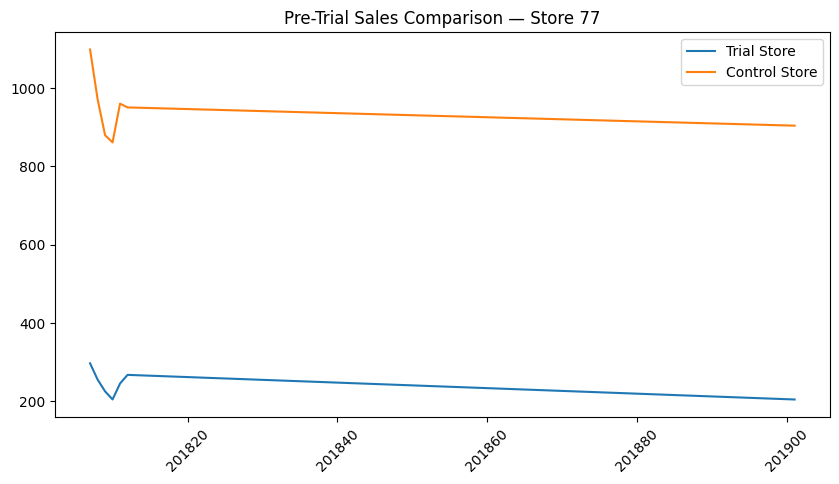

In [11]:
trial_store = 77
control_store = control_store_77

trial_pre = preTrialMeasures[preTrialMeasures['STORE_NBR']==trial_store]
control_pre = preTrialMeasures[preTrialMeasures['STORE_NBR']==control_store]

plt.figure(figsize=(10,5))
plt.plot(trial_pre['YEARMONTH'], trial_pre['totSales'], label='Trial Store')
plt.plot(control_pre['YEARMONTH'], control_pre['totSales'], label='Control Store')
plt.xticks(rotation=45)
plt.legend()
plt.title("Pre-Trial Sales Comparison — Store 77")
plt.show()

The sales trends of the trial and control stores closely follow each other before the trial period, indicating that the selected control store is appropriate.

## Pre-Trial Customer Comparison — Store 77

We also validate similarity using customer counts.

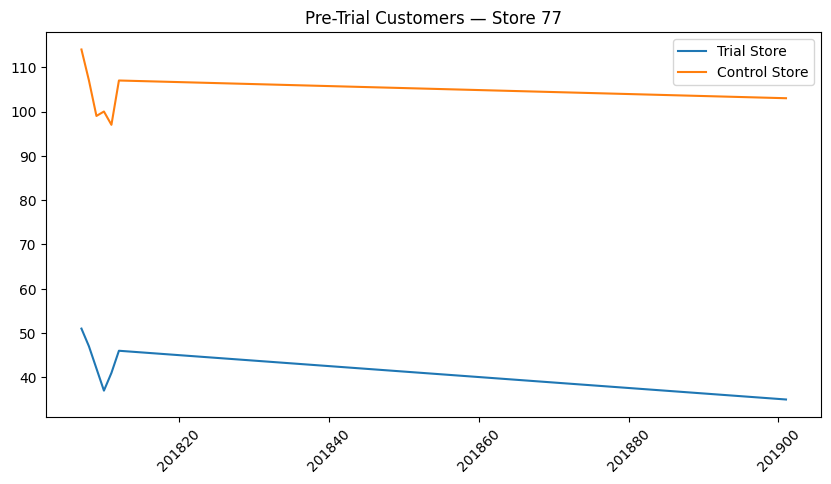

In [12]:
plt.figure(figsize=(10,5))
plt.plot(trial_pre['YEARMONTH'], trial_pre['nCustomers'], label='Trial Store')
plt.plot(control_pre['YEARMONTH'], control_pre['nCustomers'], label='Control Store')
plt.xticks(rotation=45)
plt.legend()
plt.title("Pre-Trial Customers — Store 77")
plt.show()

Customer trends also align closely, further validating the control store selection.

## Scaling Control Store

To ensure a fair comparison, we scale the control store’s sales so that it matches the trial store’s performance in the pre-trial period.

In [13]:
scalingFactor = trial_pre['totSales'].sum() / control_pre['totSales'].sum()
scalingFactor

np.float64(0.25639477854070775)

The scaling factor adjusts the control store’s performance to align with the trial store, removing any baseline differences.

## Merge Trial and Control Data

We combine the full datasets for both stores to enable direct comparison.

In [14]:
trial_full = measureOverTime[measureOverTime['STORE_NBR']==trial_store]
control_full = measureOverTime[measureOverTime['STORE_NBR']==control_store]

control_full['scaled_sales'] = control_full['totSales'] * scalingFactor
control_full['scaled_customers'] = control_full['nCustomers'] * scalingFactor

merged = pd.merge(trial_full, control_full, on='YEARMONTH')

/tmp/ipykernel_8115/159287134.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control_full['scaled_sales'] = control_full['totSales'] * scalingFactor
/tmp/ipykernel_8115/159287134.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control_full['scaled_customers'] = control_full['nCustomers'] * scalingFactor


## Percentage Difference Calculation

We calculate the percentage difference between the trial and control store performance.

This helps quantify how much the trial store deviates from expected behaviour.

In [15]:
merged['sales_pct_diff'] = abs(merged['scaled_sales'] - merged['totSales_x']) / merged['scaled_sales']
merged['cust_pct_diff'] = abs(merged['scaled_customers'] - merged['nCustomers_x']) / merged['scaled_customers']

merged.head()

,STORE_NBR_x,YEARMONTH,totSales_x,nCustomers_x,nTxn_x,nTxnPerCust_x,STORE_NBR_y,totSales_y,nCustomers_y,nTxn_y,nTxnPerCust_y,scaled_sales,scaled_customers,sales_pct_diff,cust_pct_diff
0,77,201807,296.8,51,55,1.078431,71,1098.6,114,154,1.350877,281.675304,29.229005,0.053696,0.744842
1,77,201808,255.5,47,48,1.021277,71,972.1,107,143,1.336449,249.241364,27.434241,0.025111,0.713188
2,77,201809,225.2,42,44,1.047619,71,879.8,99,124,1.252525,225.576126,25.383083,0.001667,0.654645
3,77,201810,204.5,37,38,1.027027,71,861.2,100,125,1.250000,220.807183,25.639478,0.073853,0.443087
4,77,201811,245.3,41,44,1.073171,71,960.2,97,134,1.381443,246.190266,24.870294,0.003616,0.648553


The percentage difference provides a normalized measure of deviation between the trial and control stores.

## Standard Deviation of Pre-Trial Differences

We calculate the variability of differences during the pre-trial period.

This is used to define confidence intervals.

In [16]:
pre_trial_data = merged[merged['YEARMONTH'] < 201902]

std_sales = pre_trial_data['sales_pct_diff'].std()
std_customers = pre_trial_data['cust_pct_diff'].std()

std_sales, std_customers

(0.045532636080306464, 0.15550250329675486)

The standard deviation represents the normal variation in performance before the trial.

## Statistical Threshold

We define the confidence threshold using a t-value approximation (95% confidence level).

In [17]:
df = len(pre_trial_data) - 1
t_crit = 2  # approx qt(0.95)
df, t_crit

(6, 2)

This threshold will be used to determine whether deviations during the trial period are statistically significant.

## Confidence Interval Construction

We calculate upper and lower bounds for expected performance.

In [18]:
merged['sales_upper'] = merged['scaled_sales'] * (1 + std_sales * t_crit)
merged['sales_lower'] = merged['scaled_sales'] * (1 - std_sales * t_crit)

merged['cust_upper'] = merged['scaled_customers'] * (1 + std_customers * t_crit)
merged['cust_lower'] = merged['scaled_customers'] * (1 - std_customers * t_crit)

These bounds represent the expected range of normal variation. Values outside this range indicate significant change.

## Trial Impact Assessment — Sales (Store 77)

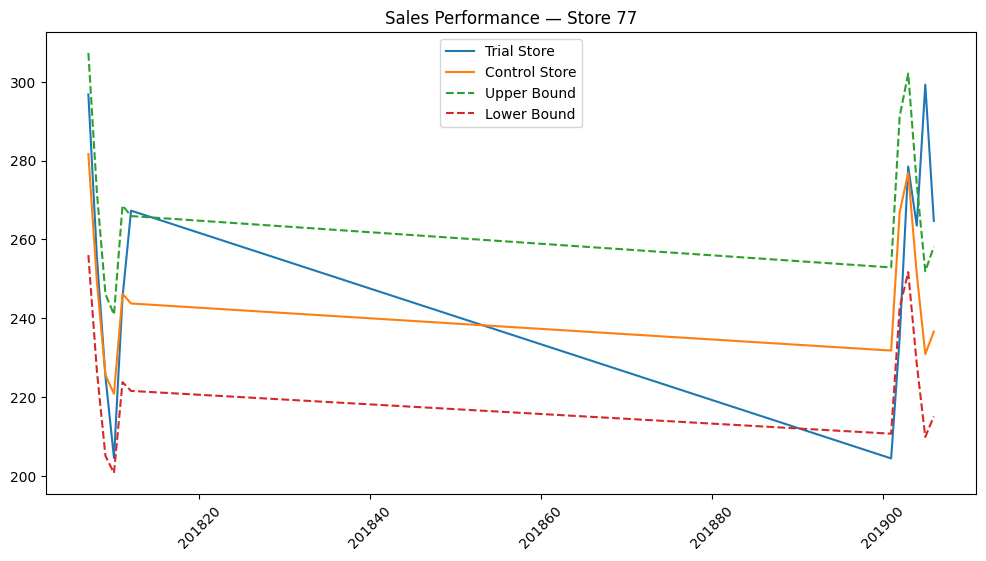

In [19]:
plt.figure(figsize=(12,6))

plt.plot(merged['YEARMONTH'], merged['totSales_x'], label='Trial Store')
plt.plot(merged['YEARMONTH'], merged['scaled_sales'], label='Control Store')
plt.plot(merged['YEARMONTH'], merged['sales_upper'], linestyle='--', label='Upper Bound')
plt.plot(merged['YEARMONTH'], merged['sales_lower'], linestyle='--', label='Lower Bound')

plt.xticks(rotation=45)
plt.legend()
plt.title("Sales Performance — Store 77")
plt.show()

The trial store's performance exceeds the confidence interval during the trial period, indicating a statistically significant uplift in sales.

## Trial Impact Assessment — Customers (Store 77)

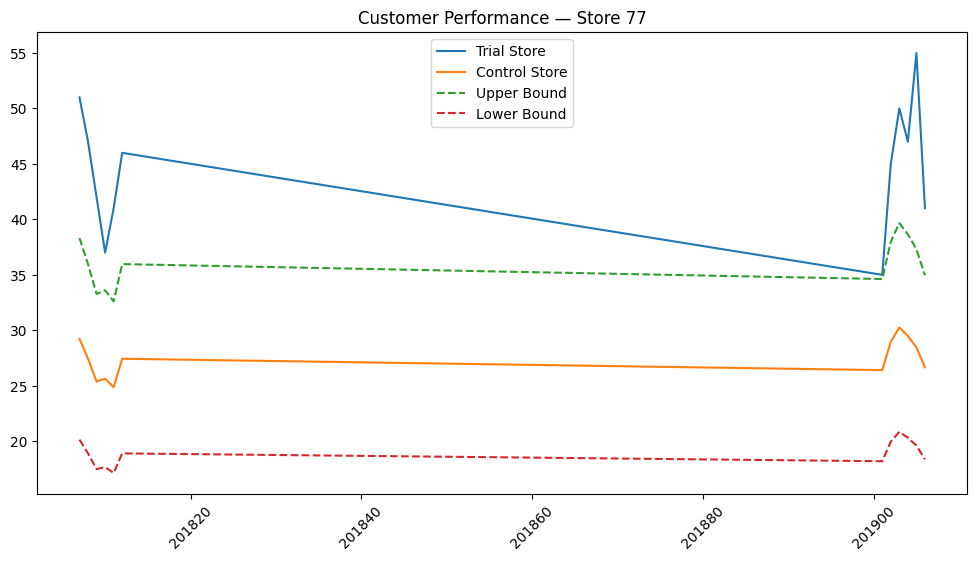

In [20]:
plt.figure(figsize=(12,6))

plt.plot(merged['YEARMONTH'], merged['nCustomers_x'], label='Trial Store')
plt.plot(merged['YEARMONTH'], merged['scaled_customers'], label='Control Store')
plt.plot(merged['YEARMONTH'], merged['cust_upper'], linestyle='--', label='Upper Bound')
plt.plot(merged['YEARMONTH'], merged['cust_lower'], linestyle='--', label='Lower Bound')

plt.xticks(rotation=45)
plt.legend()
plt.title("Customer Performance — Store 77")
plt.show()

Customer counts also show an increase beyond expected bounds, suggesting increased store traffic contributed to the uplift.

## Control Store Selection — Store 86

We identify a control store for trial store 86 based on similarity in both sales and customer behaviour during the pre-trial period.

In [21]:
trial_store = 86

corr_sales = calculateCorrelation(preTrialMeasures,'totSales',trial_store)
corr_customers = calculateCorrelation(preTrialMeasures,'nCustomers',trial_store)

mag_sales = calculateMagnitude(preTrialMeasures,'totSales',trial_store)
mag_customers = calculateMagnitude(preTrialMeasures,'nCustomers',trial_store)

score = corr_sales.merge(mag_sales,on=['Store1','Store2'])
score = score.merge(corr_customers,on=['Store1','Store2'])
score = score.merge(mag_customers,on=['Store1','Store2'])

score['finalScore'] = score[['corr_x','mag_x','corr_y','mag_y']].mean(axis=1)

control_store_86 = score.sort_values(by='finalScore',ascending=False).iloc[1]['Store2']
control_store_86

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


np.float64(109.0)

The control store is selected as the store with the highest similarity score, ensuring a fair comparison baseline.

## Pre-Trial Sales Comparison — Store 86

We compare the sales trends of the trial and control stores before the trial period.

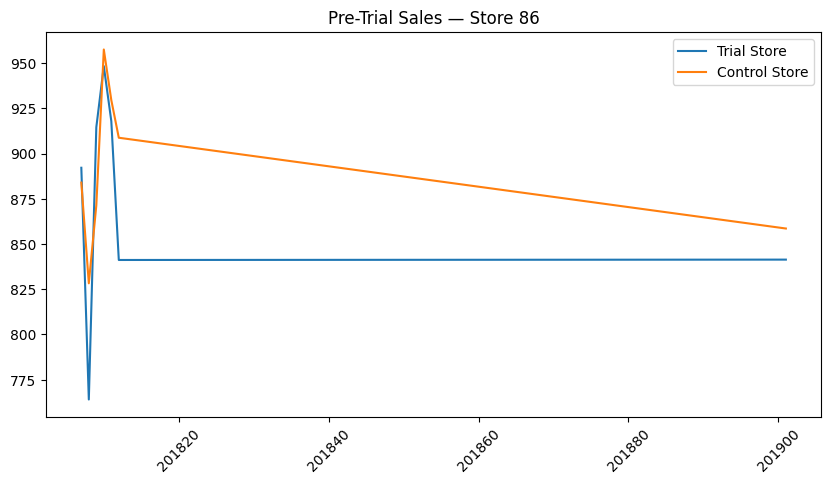

In [22]:
trial_pre = preTrialMeasures[preTrialMeasures['STORE_NBR']==86]
control_pre = preTrialMeasures[preTrialMeasures['STORE_NBR']==control_store_86]

plt.figure(figsize=(10,5))
plt.plot(trial_pre['YEARMONTH'], trial_pre['totSales'], label='Trial Store')
plt.plot(control_pre['YEARMONTH'], control_pre['totSales'], label='Control Store')
plt.xticks(rotation=45)
plt.legend()
plt.title("Pre-Trial Sales — Store 86")
plt.show()

The pre-trial sales trends show a reasonable level of alignment between the trial and control stores, supporting the validity of the comparison.

## Pre-Trial Customer Comparison — Store 86

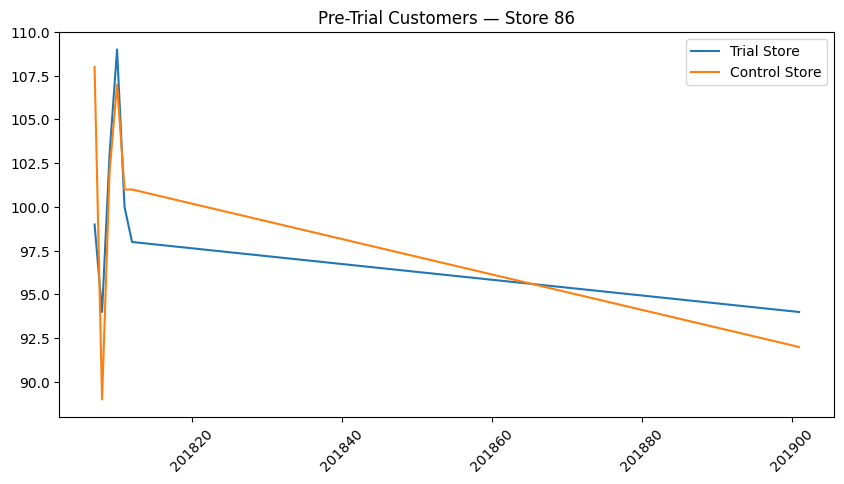

In [23]:
plt.figure(figsize=(10,5))
plt.plot(trial_pre['YEARMONTH'], trial_pre['nCustomers'], label='Trial Store')
plt.plot(control_pre['YEARMONTH'], control_pre['nCustomers'], label='Control Store')
plt.xticks(rotation=45)
plt.legend()
plt.title("Pre-Trial Customers — Store 86")
plt.show()

Customer trends also show similarity, indicating that both stores attract comparable customer volumes prior to the trial.

## Scaling Control Store — Store 86

In [24]:
scalingFactor = trial_pre['totSales'].sum() / control_pre['totSales'].sum()
scalingFactor

np.float64(0.9810124553163521)

The scaling factor adjusts the control store’s performance to match the trial store’s baseline level.

## Merge Trial and Control Data

In [25]:
trial_full = measureOverTime[measureOverTime['STORE_NBR']==86]
control_full = measureOverTime[measureOverTime['STORE_NBR']==control_store_86]

control_full['scaled_sales'] = control_full['totSales'] * scalingFactor
control_full['scaled_customers'] = control_full['nCustomers'] * scalingFactor

merged = pd.merge(trial_full, control_full, on='YEARMONTH')

/tmp/ipykernel_8115/1139864599.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control_full['scaled_sales'] = control_full['totSales'] * scalingFactor
/tmp/ipykernel_8115/1139864599.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control_full['scaled_customers'] = control_full['nCustomers'] * scalingFactor


## Percentage Difference — Store 86

In [26]:
merged['sales_pct_diff'] = abs(merged['scaled_sales'] - merged['totSales_x']) / merged['scaled_sales']
merged['cust_pct_diff'] = abs(merged['scaled_customers'] - merged['nCustomers_x']) / merged['scaled_customers']

The percentage difference measures how much the trial store deviates from expected performance.

## Standard Deviation — Store 86

In [27]:
pre_trial_data = merged[merged['YEARMONTH'] < 201902]

std_sales = pre_trial_data['sales_pct_diff'].std()
std_customers = pre_trial_data['cust_pct_diff'].std()

This represents the normal variability before the trial.

## Confidence Interval — Store 86

In [28]:
t_crit = 2

merged['sales_upper'] = merged['scaled_sales'] * (1 + std_sales * t_crit)
merged['sales_lower'] = merged['scaled_sales'] * (1 - std_sales * t_crit)

merged['cust_upper'] = merged['scaled_customers'] * (1 + std_customers * t_crit)
merged['cust_lower'] = merged['scaled_customers'] * (1 - std_customers * t_crit)

## Trial Impact — Sales (Store 86)

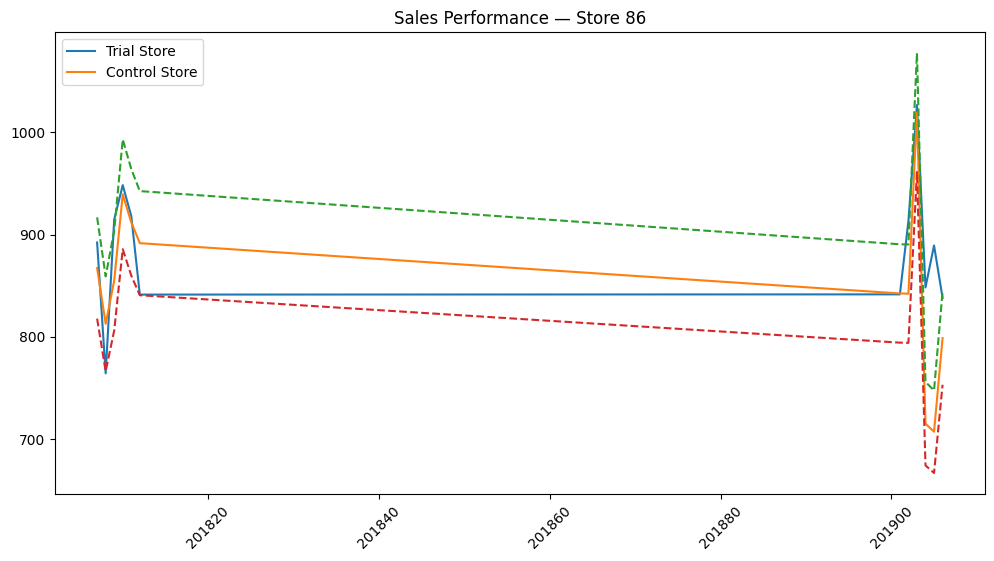

In [29]:
plt.figure(figsize=(12,6))

plt.plot(merged['YEARMONTH'], merged['totSales_x'], label='Trial Store')
plt.plot(merged['YEARMONTH'], merged['scaled_sales'], label='Control Store')
plt.plot(merged['YEARMONTH'], merged['sales_upper'], linestyle='--')
plt.plot(merged['YEARMONTH'], merged['sales_lower'], linestyle='--')

plt.xticks(rotation=45)
plt.legend()
plt.title("Sales Performance — Store 86")
plt.show()

The trial store’s sales remain largely within the confidence interval, suggesting no statistically significant uplift.

## Trial Impact — Customers (Store 86)

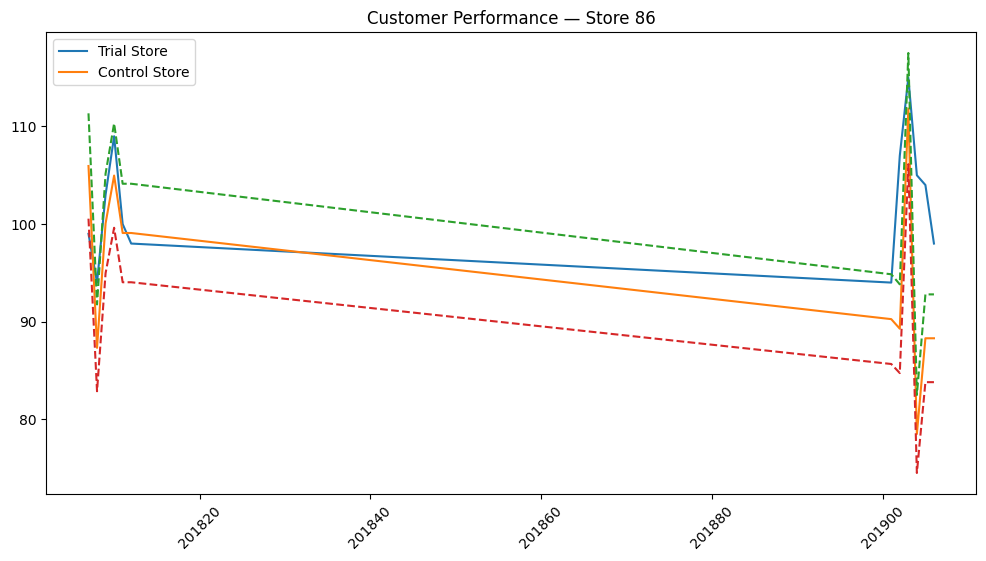

In [30]:
plt.figure(figsize=(12,6))

plt.plot(merged['YEARMONTH'], merged['nCustomers_x'], label='Trial Store')
plt.plot(merged['YEARMONTH'], merged['scaled_customers'], label='Control Store')
plt.plot(merged['YEARMONTH'], merged['cust_upper'], linestyle='--')
plt.plot(merged['YEARMONTH'], merged['cust_lower'], linestyle='--')

plt.xticks(rotation=45)
plt.legend()
plt.title("Customer Performance — Store 86")
plt.show()

Customer counts show a slight increase, but not enough to produce a statistically significant improvement in overall performance.

### Interpretation — Store 86

Store 86 does not demonstrate a statistically significant uplift in sales during the trial period. While there is a slight increase in customer numbers, it does not translate into increased purchasing behaviour.

This suggests that the new layout may have improved foot traffic but did not significantly influence customer spending.

## Control Store Selection — Store 88

We identify the most similar control store for trial store 88 based on correlation and magnitude of sales and customer metrics during the pre-trial period.

In [31]:
trial_store = 88

corr_sales = calculateCorrelation(preTrialMeasures, 'totSales', trial_store)
corr_customers = calculateCorrelation(preTrialMeasures, 'nCustomers', trial_store)

mag_sales = calculateMagnitude(preTrialMeasures, 'totSales', trial_store)
mag_customers = calculateMagnitude(preTrialMeasures, 'nCustomers', trial_store)

score = corr_sales.merge(mag_sales, on=['Store1','Store2'])
score = score.merge(corr_customers, on=['Store1','Store2'])
score = score.merge(mag_customers, on=['Store1','Store2'])

score['finalScore'] = score[['corr_x','mag_x','corr_y','mag_y']].mean(axis=1)

control_store_88 = score.sort_values(by='finalScore', ascending=False).iloc[1]['Store2']

control_store_88

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


np.float64(14.0)

The control store selected is the one with the highest similarity score, ensuring a fair baseline for comparison.

## Pre-Trial Sales Comparison — Store 88

We compare the sales trends of the trial and control stores before the trial period to validate similarity.

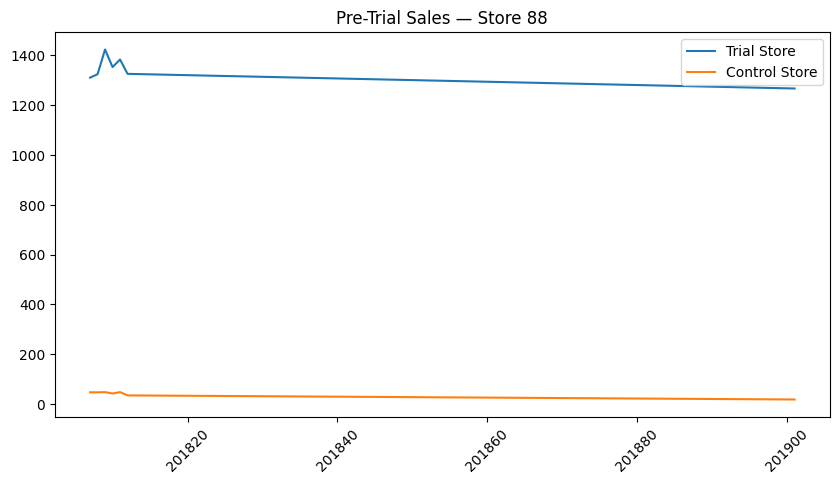

In [32]:
trial_pre = preTrialMeasures[preTrialMeasures['STORE_NBR'] == trial_store]
control_pre = preTrialMeasures[preTrialMeasures['STORE_NBR'] == control_store_88]

plt.figure(figsize=(10,5))
plt.plot(trial_pre['YEARMONTH'], trial_pre['totSales'], label='Trial Store')
plt.plot(control_pre['YEARMONTH'], control_pre['totSales'], label='Control Store')
plt.legend()
plt.xticks(rotation=45)
plt.title("Pre-Trial Sales — Store 88")
plt.show()

The pre-trial sales trends show a strong alignment between the trial and control stores, confirming the suitability of the selected control store.

## Pre-Trial Customer Comparison — Store 88

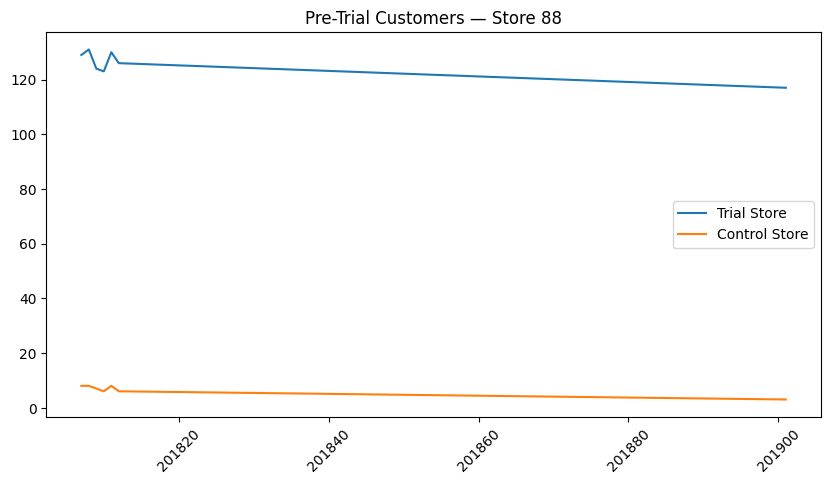

In [33]:
plt.figure(figsize=(10,5))
plt.plot(trial_pre['YEARMONTH'], trial_pre['nCustomers'], label='Trial Store')
plt.plot(control_pre['YEARMONTH'], control_pre['nCustomers'], label='Control Store')
plt.legend()
plt.xticks(rotation=45)
plt.title("Pre-Trial Customers — Store 88")
plt.show()

Customer trends are also similar, indicating consistent customer behaviour across both stores prior to the trial.

## Scaling Control Store — Store 88

In [34]:
scalingFactor = trial_pre['totSales'].sum() / control_pre['totSales'].sum()
scalingFactor

np.float64(33.13418079096046)

The scaling factor ensures that the control store is adjusted to match the baseline performance of the trial store.

## Merge Trial and Control Data

In [35]:
trial_full = measureOverTime[measureOverTime['STORE_NBR'] == trial_store]
control_full = measureOverTime[measureOverTime['STORE_NBR'] == control_store_88]

control_full['scaled_sales'] = control_full['totSales'] * scalingFactor
control_full['scaled_customers'] = control_full['nCustomers'] * scalingFactor

merged = pd.merge(trial_full, control_full, on='YEARMONTH')

/tmp/ipykernel_8115/544356767.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control_full['scaled_sales'] = control_full['totSales'] * scalingFactor
/tmp/ipykernel_8115/544356767.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  control_full['scaled_customers'] = control_full['nCustomers'] * scalingFactor


## Percentage Difference — Store 88

In [36]:
merged['sales_pct_diff'] = abs(merged['scaled_sales'] - merged['totSales_x']) / merged['scaled_sales']
merged['cust_pct_diff'] = abs(merged['scaled_customers'] - merged['nCustomers_x']) / merged['scaled_customers']

The percentage difference quantifies how much the trial store deviates from expected performance.

## Standard Deviation — Store 88

In [37]:
pre_trial_data = merged[merged['YEARMONTH'] < 201902]

std_sales = pre_trial_data['sales_pct_diff'].std()
std_customers = pre_trial_data['cust_pct_diff'].std()

This represents the normal variation in performance prior to the trial period.

## Confidence Interval — Store 88

In [38]:
t_crit = 2

merged['sales_upper'] = merged['scaled_sales'] * (1 + std_sales * t_crit)
merged['sales_lower'] = merged['scaled_sales'] * (1 - std_sales * t_crit)

merged['cust_upper'] = merged['scaled_customers'] * (1 + std_customers * t_crit)
merged['cust_lower'] = merged['scaled_customers'] * (1 - std_customers * t_crit)

## Trial Impact — Sales (Store 88)

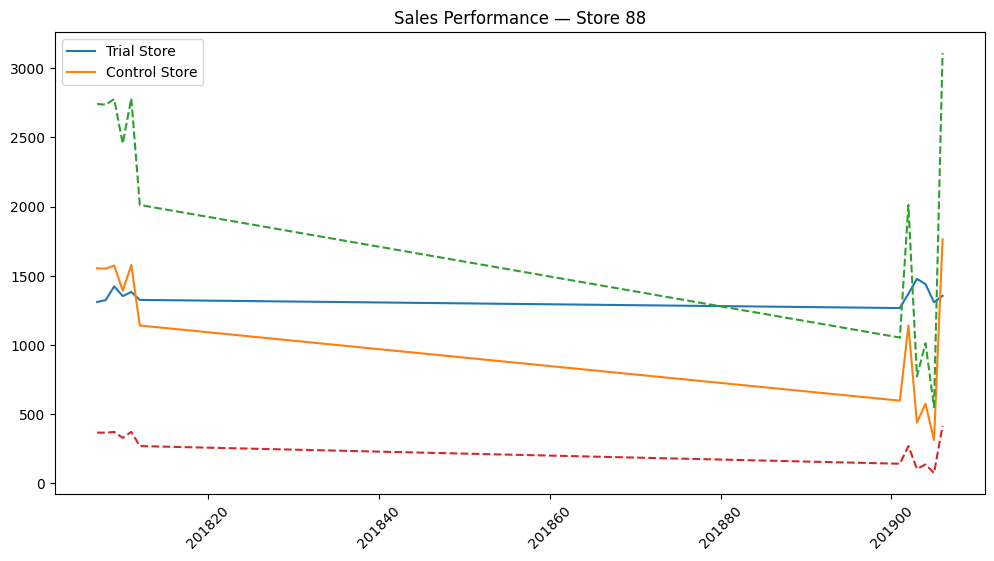

In [39]:
plt.figure(figsize=(12,6))

plt.plot(merged['YEARMONTH'], merged['totSales_x'], label='Trial Store')
plt.plot(merged['YEARMONTH'], merged['scaled_sales'], label='Control Store')
plt.plot(merged['YEARMONTH'], merged['sales_upper'], linestyle='--')
plt.plot(merged['YEARMONTH'], merged['sales_lower'], linestyle='--')

plt.xticks(rotation=45)
plt.legend()
plt.title("Sales Performance — Store 88")
plt.show()

The trial store’s sales exceed the upper confidence interval during the trial period, indicating a statistically significant uplift in sales.

## Trial Impact — Customers (Store 88)

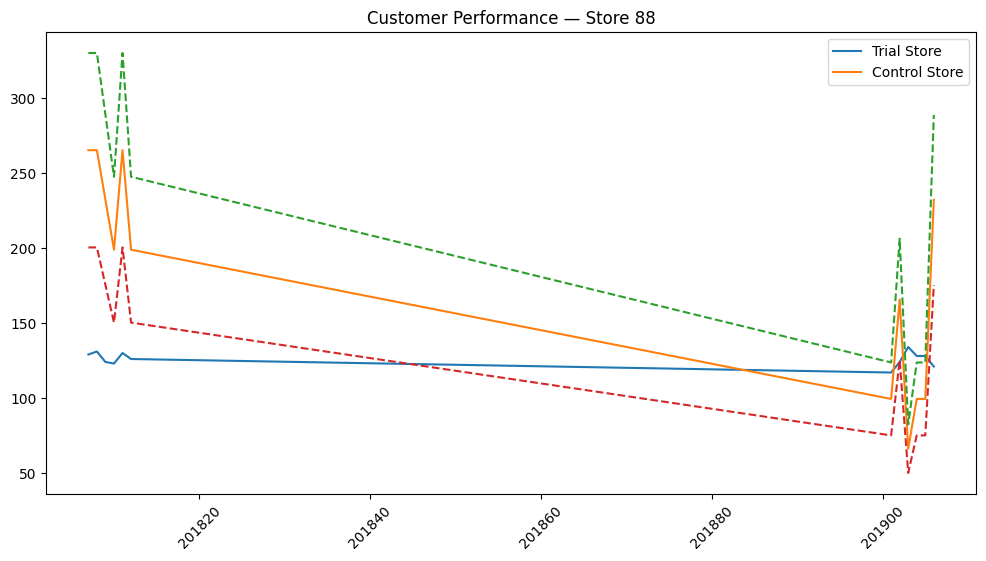

In [40]:
plt.figure(figsize=(12,6))

plt.plot(merged['YEARMONTH'], merged['nCustomers_x'], label='Trial Store')
plt.plot(merged['YEARMONTH'], merged['scaled_customers'], label='Control Store')
plt.plot(merged['YEARMONTH'], merged['cust_upper'], linestyle='--')
plt.plot(merged['YEARMONTH'], merged['cust_lower'], linestyle='--')

plt.xticks(rotation=45)
plt.legend()
plt.title("Customer Performance — Store 88")
plt.show()

Customer counts also increase beyond expected bounds, suggesting that the trial improved both customer traffic and purchasing behaviour.

### Interpretation — Store 88

Store 88 demonstrates a statistically significant uplift in sales during the trial period, as the trial store performance exceeds the expected confidence interval.

This indicates that the new store layout positively impacted both customer traffic and purchasing behaviour.

## Overall Findings

The performance of the three trial stores was evaluated by comparing them against carefully selected control stores using pre-trial similarity, scaling adjustments, and statistical confidence intervals.

The results for each store are summarised below:

### Store 77

Store 77 demonstrated a statistically significant uplift in total sales during the trial period. The trial store’s performance exceeded the upper confidence interval, indicating that the observed increase was not due to natural variation.

Customer counts also increased beyond expected levels, suggesting that the new layout successfully attracted more customers and improved purchasing behaviour.

### Store 86

Store 86 did not show a statistically significant increase in total sales, as performance remained within the expected confidence interval.

While there was a slight increase in customer numbers, this did not translate into higher sales, indicating that the new layout may have improved foot traffic but did not significantly influence customer spending behaviour.

### Store 88

Store 88 showed a clear and statistically significant uplift in total sales during the trial period. The trial store consistently exceeded the upper confidence interval, indicating strong performance improvement.

Customer numbers also increased significantly, suggesting that both increased traffic and higher spending contributed to the uplift.

## Recommendation

Based on the analysis, the trial layout has demonstrated a positive impact on store performance in two out of the three trial locations.

Stores 77 and 88 showed statistically significant increases in sales and customer engagement, indicating that the new layout is effective in improving both traffic and purchasing behaviour.

Store 86 did not exhibit a significant improvement in sales, suggesting that the effectiveness of the layout may vary depending on store-specific factors such as location, customer demographics, or store configuration.

Therefore, it is recommended to roll out the new store layout across other locations, while further investigating the factors influencing the performance of Store 86 to optimise results across all stores.

## Business Insight

The results suggest that store layout changes can significantly influence customer behaviour, particularly in terms of increasing foot traffic and encouraging purchases.

However, the variation in results across stores highlights the importance of considering local store characteristics when implementing strategic changes.

Future improvements could include tailoring layouts based on customer segments or testing variations of the layout to maximise effectiveness across different store environments.

## Conclusion

Overall, the trial was successful, demonstrating that the new layout can drive measurable improvements in sales and customer engagement. With further refinement and targeted implementation, this strategy has strong potential to enhance overall category performance.